In [1]:
import pandas as pd


In [9]:
df=pd.read_csv("D:\DODO\job_JCZu6xphFZ93_E6LfvWzDGKzcetS.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Menna\AppData\Local\Temp\ipykernel_11952\2465123526.py:1: SyntaxWarning: invalid escape sequence '\D'
  df=pd.read_csv("D:\DODO\job_JCZu6xphFZ93_E6LfvWzDGKzcetS.csv")


In [10]:
df.head()

,time,active_instances,avg_cpu_usage,total_cpu_usage,peak_cpu_usage,avg_memory_usage,total_memory_usage,peak_memory_usage,avg_assigned_memory
0,3.000000e+08,542685,0.006544,3551.510054,23.500000,0.005007,2717.409354,0.575195,0.009078
1,6.000000e+08,544048,0.006131,3335.573962,8.343750,0.004945,2690.372926,0.576172,0.009006
2,9.000000e+08,547729,0.005964,3266.486724,8.328125,0.004829,2644.980895,0.576172,0.008989
3,1.200000e+09,552011,0.006489,3581.727827,7.179688,0.004912,2711.474361,0.575195,0.009002
4,1.500000e+09,556719,0.006788,3778.848942,10.140625,0.004958,2760.266188,0.575195,0.008970


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8929 entries, 0 to 8928
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   time                 8929 non-null   float64
 1   active_instances     8929 non-null   int64  
 2   avg_cpu_usage        8929 non-null   float64
 3   total_cpu_usage      8929 non-null   float64
 4   peak_cpu_usage       8929 non-null   float64
 5   avg_memory_usage     8929 non-null   float64
 6   total_memory_usage   8929 non-null   float64
 7   peak_memory_usage    8929 non-null   float64
 8   avg_assigned_memory  8929 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 627.9 KB


In [14]:
df["datetime"] = (
    pd.Timestamp("2019-05-01 00:00:00")
    + pd.to_timedelta(df["time"], unit="us")
)

In [15]:
df.head()

,time,active_instances,avg_cpu_usage,total_cpu_usage,peak_cpu_usage,avg_memory_usage,total_memory_usage,peak_memory_usage,avg_assigned_memory,datetime
0,3.000000e+08,542685,0.006544,3551.510054,23.500000,0.005007,2717.409354,0.575195,0.009078,2019-05-01 00:05:00
1,6.000000e+08,544048,0.006131,3335.573962,8.343750,0.004945,2690.372926,0.576172,0.009006,2019-05-01 00:10:00
2,9.000000e+08,547729,0.005964,3266.486724,8.328125,0.004829,2644.980895,0.576172,0.008989,2019-05-01 00:15:00
3,1.200000e+09,552011,0.006489,3581.727827,7.179688,0.004912,2711.474361,0.575195,0.009002,2019-05-01 00:20:00
4,1.500000e+09,556719,0.006788,3778.848942,10.140625,0.004958,2760.266188,0.575195,0.008970,2019-05-01 00:25:00


In [16]:
df["datetime"] = (
    pd.Timestamp("2019-05-01 00:00:00")
    + pd.to_timedelta(df["time"], unit="us")
)

# Move datetime to first column
cols = ["datetime"] + [col for col in df.columns if col != "datetime"]
df = df[cols]

In [17]:
df = df.drop(columns=["time"])

In [18]:
df.head()

,datetime,active_instances,avg_cpu_usage,total_cpu_usage,peak_cpu_usage,avg_memory_usage,total_memory_usage,peak_memory_usage,avg_assigned_memory
0,2019-05-01 00:05:00,542685,0.006544,3551.510054,23.500000,0.005007,2717.409354,0.575195,0.009078
1,2019-05-01 00:10:00,544048,0.006131,3335.573962,8.343750,0.004945,2690.372926,0.576172,0.009006
2,2019-05-01 00:15:00,547729,0.005964,3266.486724,8.328125,0.004829,2644.980895,0.576172,0.008989
3,2019-05-01 00:20:00,552011,0.006489,3581.727827,7.179688,0.004912,2711.474361,0.575195,0.009002
4,2019-05-01 00:25:00,556719,0.006788,3778.848942,10.140625,0.004958,2760.266188,0.575195,0.008970


In [19]:
df.isnull().sum()

datetime               0
active_instances       0
avg_cpu_usage          0
total_cpu_usage        0
peak_cpu_usage         0
avg_memory_usage       0
total_memory_usage     0
peak_memory_usage      0
avg_assigned_memory    0
dtype: int64

In [20]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate datetimes:", df["datetime"].duplicated().sum())

Duplicate rows: 0
Duplicate datetimes: 0


In [21]:
numeric_cols = [
    "active_instances",
    "avg_cpu_usage",
    "total_cpu_usage",
    "peak_cpu_usage",
    "avg_memory_usage",
    "total_memory_usage",
    "peak_memory_usage",
    "avg_assigned_memory"
]

(df[numeric_cols] < 0).sum()

active_instances       0
avg_cpu_usage          0
total_cpu_usage        0
peak_cpu_usage         0
avg_memory_usage       0
total_memory_usage     0
peak_memory_usage      0
avg_assigned_memory    0
dtype: int64

In [22]:
df[numeric_cols].agg(["min", "max", "mean", "median", "std"]).T

,min,max,mean,median,std
active_instances,426535.000000,703501.000000,581992.270915,578498.000000,28518.280446
avg_cpu_usage,0.004119,0.008513,0.006604,0.006625,0.000770
total_cpu_usage,2269.479877,4737.619676,3833.723758,3863.816586,400.499515
peak_cpu_usage,2.554688,154.500000,7.366371,6.398438,4.750419
avg_memory_usage,0.003362,0.005668,0.004705,0.004762,0.000393
total_memory_usage,2069.717911,3107.877220,2731.022936,2741.556074,175.218951
peak_memory_usage,0.197510,0.585938,0.521334,0.552734,0.096380
avg_assigned_memory,0.007191,0.011922,0.009449,0.009478,0.000554


In [23]:
df["time_diff"] = df["datetime"].diff()
df["time_diff"].value_counts()

time_diff
0 days 00:05:00    8928
Name: count, dtype: int64

In [24]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,8929,2019-05-16 12:05:00,2019-05-01 00:05:00,2019-05-08 18:05:00,2019-05-16 12:05:00,2019-05-24 06:05:00,2019-06-01 00:05:00,NaN
active_instances,8929.0,581992.270915,426535.0,563369.0,578498.0,597212.0,703501.0,28518.280446
avg_cpu_usage,8929.0,0.006604,0.004119,0.006077,0.006625,0.007202,0.008513,0.00077
total_cpu_usage,8929.0,3833.723758,2269.479877,3562.576909,3863.816586,4145.995887,4737.619676,400.499515
peak_cpu_usage,8929.0,7.366371,2.554688,5.101562,6.398438,8.296875,154.5,4.750419
avg_memory_usage,8929.0,0.004705,0.003362,0.004436,0.004762,0.005025,0.005668,0.000393
total_memory_usage,8929.0,2731.022936,2069.717911,2618.208369,2741.556074,2876.318682,3107.87722,175.218951
peak_memory_usage,8929.0,0.521334,0.19751,0.546875,0.552734,0.561523,0.585938,0.09638
avg_assigned_memory,8929.0,0.009449,0.007191,0.009127,0.009478,0.009745,0.011922,0.000554
time_diff,8928,0 days 00:05:00,0 days 00:05:00,0 days 00:05:00,0 days 00:05:00,0 days 00:05:00,0 days 00:05:00,0 days 00:00:00


In [25]:
print(df["datetime"].min())
print(df["datetime"].max())

print(df["datetime"].diff().value_counts().head())

2019-05-01 00:05:00
2019-06-01 00:05:00
datetime
0 days 00:05:00    8928
Name: count, dtype: int64


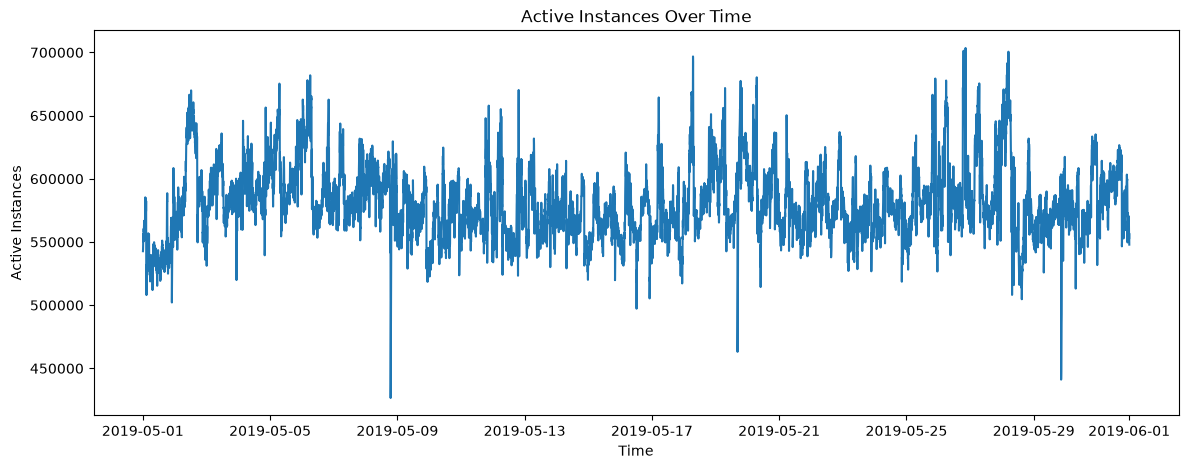

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(df["datetime"], df["active_instances"])
plt.xlabel("Time")
plt.ylabel("Active Instances")
plt.title("Active Instances Over Time")
plt.show()

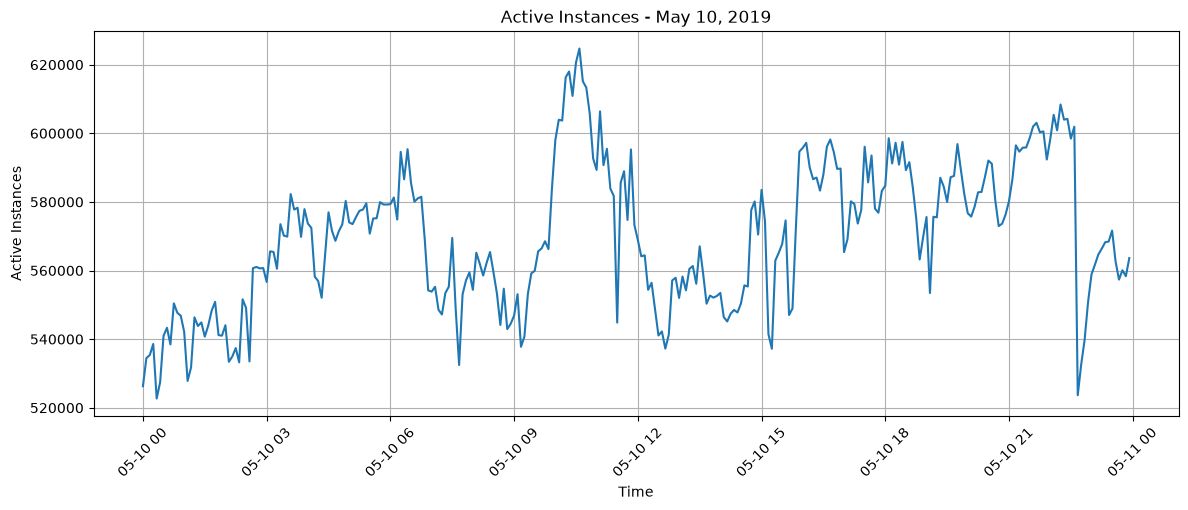

In [27]:
start = "2019-05-10"
end = "2019-05-11"

df_day = df[
    (df["datetime"] >= start) &
    (df["datetime"] < end)
]

plt.figure(figsize=(14,5))
plt.plot(df_day["datetime"], df_day["active_instances"])

plt.xlabel("Time")
plt.ylabel("Active Instances")
plt.title("Active Instances - May 10, 2019")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

The workload is highly dynamic within a single day. Active instances vary roughly from 520k to 625k for most of the day, so the cluster workload is definitely not constant.
There is a clear morning increase. Around midnight the workload is near 530k–550k, then it generally rises toward 570k–590k in the early morning.
The strongest visible peak occurs around 10:00, reaching roughly 625k active instances. This is a good example of the type of workload increase your predictive autoscaling model should learn to anticipate.
After that peak, there is a fairly rapid decline toward roughly 540k–560k around noon–early afternoon.
The workload rises again during the afternoon and evening. From around 15:00 onward, there are repeated periods near 580k–600k, so the day appears to contain multiple workload cycles rather than one simple peak.
There are several very sharp drops, for example around roughly 11:30, 15:00, and especially around 22:30. These deserve investigation. They could be real workload changes, but they could also reflect scheduling behavior, instance termination, aggregation effects, or unusual events.

In [31]:
df["hour"] = df["datetime"].dt.hour

instances_by_hour = (
    df.groupby("hour")["active_instances"]
      .mean()
)

print(instances_by_hour)

hour
0     576370.206434
1     575691.061828
2     572342.161290
3     582599.325269
4     599018.268817
5     600680.594086
6     602089.569892
7     587314.026882
8     579768.760753
9     580809.540323
10    574715.077957
11    572105.637097
12    573374.905914
13    572561.889785
14    571454.623656
15    574960.524194
16    578055.290323
17    575814.239247
18    585221.693548
19    596075.736559
20    593477.658602
21    587529.975806
22    579696.852151
23    576101.994624
Name: active_instances, dtype: float64


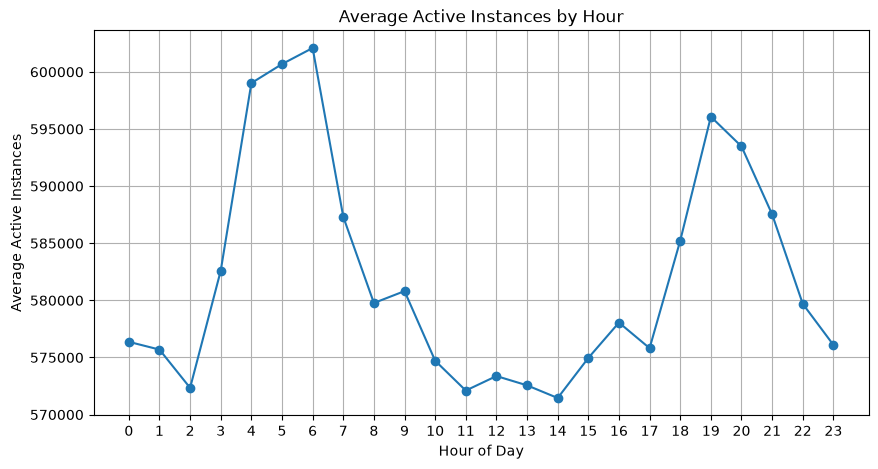

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(instances_by_hour.index, instances_by_hour.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Active Instances")
plt.title("Average Active Instances by Hour")
plt.xticks(range(24))
plt.grid(True)
plt.show()

Early morning peak: around 04:00–06:00, with the highest average near 06:00, a little above 600,000 active instances.
Evening peak: around 18:00–21:00, with another high point near 19:00, around 596,000 active instances.

In [28]:
df["hour"] = df["datetime"].dt.hour

In [29]:
hourly = df.groupby("hour")[
    ["active_instances", "total_cpu_usage", "total_memory_usage"]
].mean()

hourly

,active_instances,total_cpu_usage,total_memory_usage
hour,,,
0,576370.206434,3546.367762,2580.567317
1,575691.061828,3537.125384,2636.595083
2,572342.161290,3611.754024,2670.693964
3,582599.325269,3618.245593,2579.768189
4,599018.268817,3790.074624,2573.207322
5,600680.594086,3919.499562,2662.764983
6,602089.569892,3923.816375,2681.227223
7,587314.026882,3951.174739,2706.143174
8,579768.760753,4030.519372,2855.144299


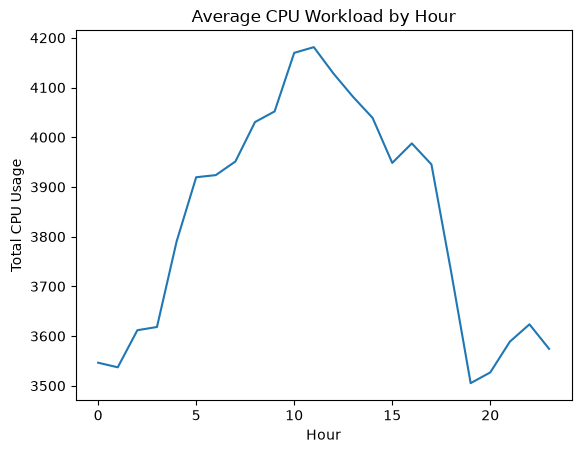

In [30]:
hourly["total_cpu_usage"].plot()
plt.title("Average CPU Workload by Hour")
plt.xlabel("Hour")
plt.ylabel("Total CPU Usage")
plt.show()

In [36]:
df["day_of_week"] = df["datetime"].dt.day_name()

In [37]:
df[
    [
        "active_instances",
        "avg_cpu_usage",
        "total_cpu_usage",
        "avg_memory_usage",
        "total_memory_usage"
    ]
].corr()

,active_instances,avg_cpu_usage,total_cpu_usage,avg_memory_usage,total_memory_usage
active_instances,1.000000,-0.443480,-0.050334,-0.655453,-0.128935
avg_cpu_usage,-0.443480,1.000000,0.916227,0.656505,0.531925
total_cpu_usage,-0.050334,0.916227,1.000000,0.438768,0.535143
avg_memory_usage,-0.655453,0.656505,0.438768,1.000000,0.831596
total_memory_usage,-0.128935,0.531925,0.535143,0.831596,1.000000


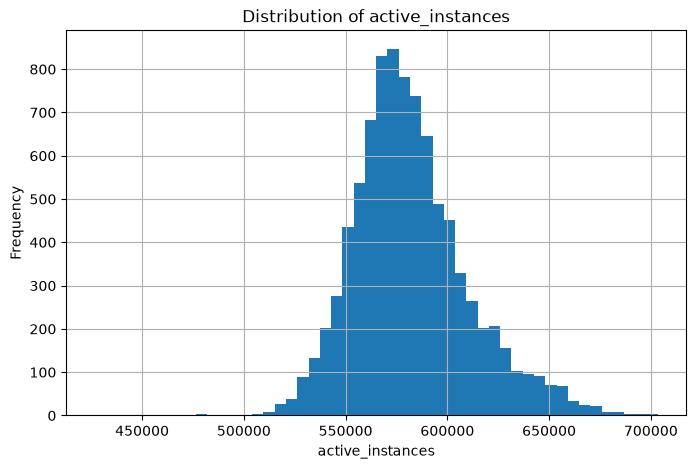

active_instances skewness = 0.5933


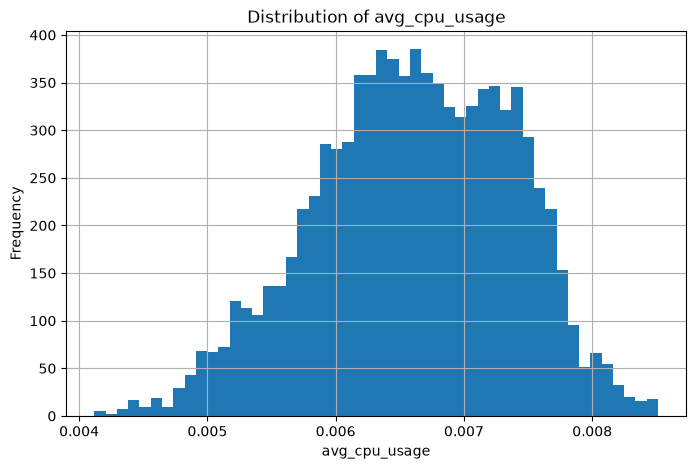

avg_cpu_usage skewness = -0.2453


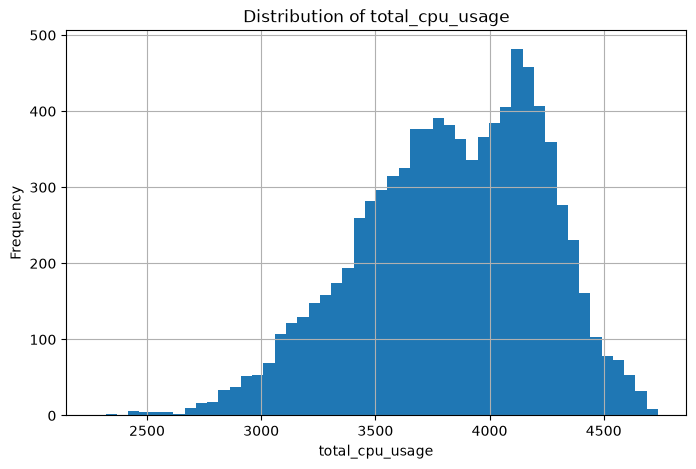

total_cpu_usage skewness = -0.4177


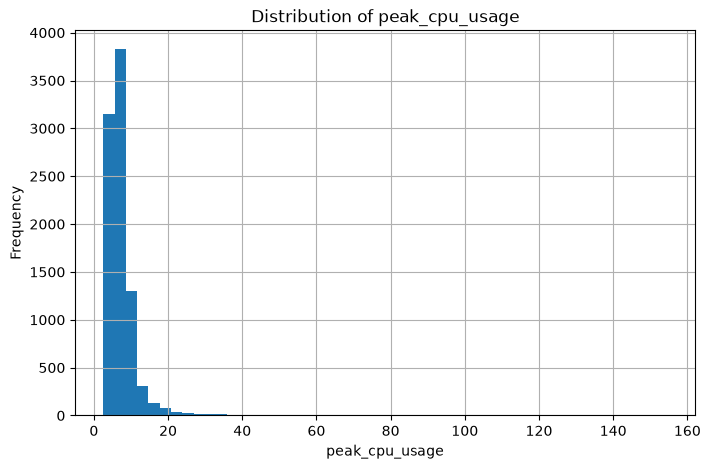

peak_cpu_usage skewness = 9.5036


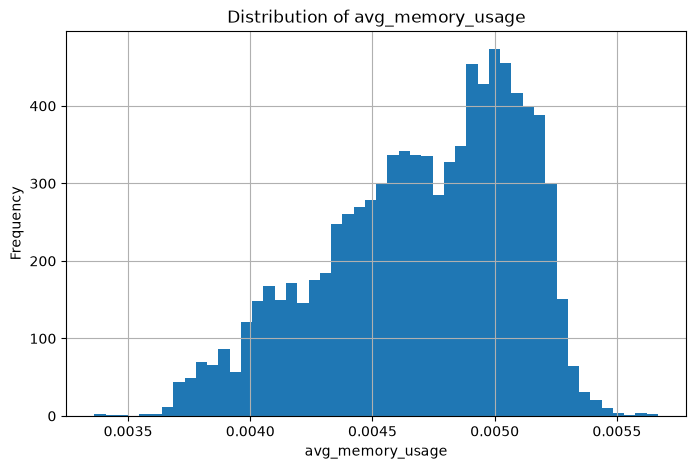

avg_memory_usage skewness = -0.5251


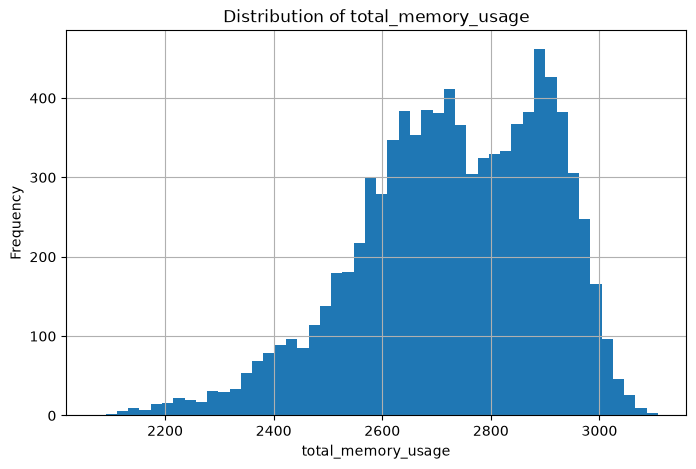

total_memory_usage skewness = -0.5607


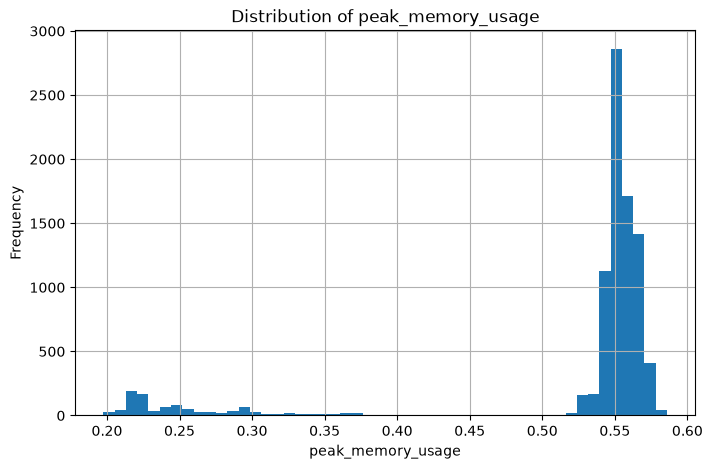

peak_memory_usage skewness = -2.5146


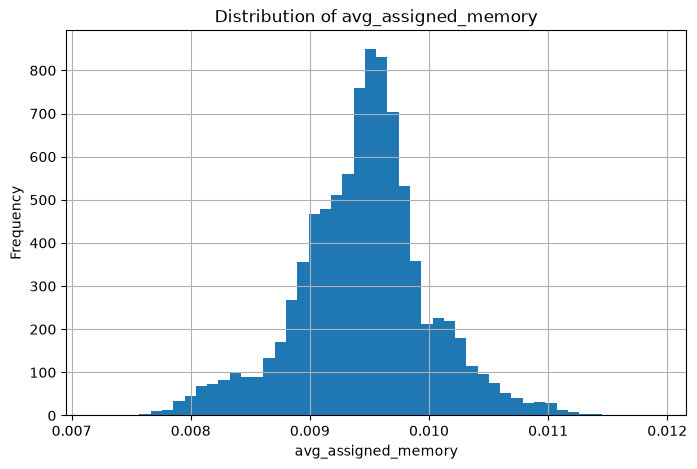

avg_assigned_memory skewness = -0.0900


In [39]:
columns = [
    "active_instances",
    "avg_cpu_usage",
    "total_cpu_usage",
    "peak_cpu_usage",
    "avg_memory_usage",
    "total_memory_usage",
    "peak_memory_usage",
    "avg_assigned_memory"
]

for col in columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    print(f"{col} skewness = {df[col].skew():.4f}")

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate datetimes:", df["datetime"].duplicated().sum())

Duplicate rows: 0
Duplicate datetimes: 0


--Active Instances: The distribution of active instances is approximately bell-shaped with a slight right skew. Most observations are concentrated around roughly 560,000–600,000 active instances, while fewer intervals show very low or very high numbers of active instances. The longer right tail indicates that unusually high workload periods occur occasionally, but the majority of the cluster activity stays around a relatively stable central range.

--Total CPU Usage: The distribution of total CPU usage is concentrated mainly between approximately 3,400 and 4,400, with the largest concentration around 4,000–4,200. The distribution appears slightly left-skewed, since the lower-usage tail extends further toward values near 2,300–3,000. The shape is also not perfectly unimodal, suggesting that the cluster may operate under several different workload states during the month rather than remaining around one constant CPU-demand level.

--Peak CPU Usage: Peak CPU usage is strongly right-skewed. Most observations are concentrated at relatively low peak values, mainly around roughly 3–12, while a small number of intervals extend to much higher values. This long right tail suggests the existence of occasional extreme CPU spikes. These observations are especially important for the autoscaling project because even if average resource usage is stable, short periods of very high CPU demand may create performance problems if capacity is not increased quickly enough.

--Average Memory Usage: Average memory usage is concentrated mostly around approximately 0.0043–0.0052, with the highest density near 0.005. The distribution is slightly left-skewed, as a longer tail extends toward lower memory-usage values. This suggests that the typical instance operates within a relatively narrow memory range, while some periods experience noticeably lower average memory utilization.

--Total Memory Usage: Total memory usage is mainly concentrated between approximately 2,500 and 3,000, with visible concentration regions around roughly 2,650–2,750 and 2,850–2,950. The distribution is slightly left-skewed and somewhat multimodal, suggesting that total memory demand may vary between different workload regimes. This may correspond to different levels of active workload or different operating periods during the day.

--Peak Memory Usage: Peak memory usage has a very unusual distribution. Most observations are strongly concentrated around approximately 0.54–0.57, particularly near 0.55, while a much smaller group of observations appears between approximately 0.20 and 0.40. This creates a strongly left-skewed distribution with a separate low-value tail. The distinct lower-value group should be investigated further because it may represent different workload conditions, resource configurations, or unusual periods in the cluster.

--Average Assigned Memory: Average assigned memory has an approximately bell-shaped distribution centered around roughly 0.0094–0.0097, although it shows some right skew. Most values remain within a relatively narrow range, suggesting that memory allocation is fairly stable across the month. The right tail toward values above 0.0105 indicates that some periods received noticeably more allocated memory than usual. Comparing this feature with actual memory usage can help identify possible overprovisioning.


Taken together, the distributions show that the Google cluster operates under multiple workload levels rather than one completely stable condition. Average resource variables are relatively concentrated, while peak CPU usage contains strong extreme values and total CPU/memory usage shows broader variation. This is useful for your project because the ML model must learn both regular workload patterns and occasional high-resource periods. The results support using historical lag features, rolling statistics, time-of-day features, and peak-related variables when predicting future workload for proactive Kubernetes scaling.

In [40]:
df.nlargest(10, "total_cpu_usage")[
    ["datetime", "active_instances", "total_cpu_usage", "peak_cpu_usage"]
]

,datetime,active_instances,total_cpu_usage,peak_cpu_usage
2681,2019-05-10 07:30:00,569496,4737.619676,5.484375
3539,2019-05-13 07:00:00,631864,4728.890652,8.656250
3542,2019-05-13 07:15:00,609039,4717.496928,9.968750
4449,2019-05-16 10:50:00,556149,4704.132782,8.187500
4460,2019-05-16 11:45:00,557618,4702.625402,5.007812
3540,2019-05-13 07:05:00,627256,4698.858115,9.078125
4459,2019-05-16 11:40:00,560306,4695.206539,4.789062
3541,2019-05-13 07:10:00,612843,4695.036184,6.929688
4453,2019-05-16 11:10:00,562566,4689.531195,8.031250
4466,2019-05-16 12:15:00,556301,4687.525293,5.632812


In [41]:
df.nlargest(10, "total_memory_usage")

,datetime,active_instances,avg_cpu_usage,total_cpu_usage,peak_cpu_usage,avg_memory_usage,total_memory_usage,peak_memory_usage,avg_assigned_memory,time_diff,hour,day_of_week
996,2019-05-04 11:05:00,591212,0.007525,4448.781490,3.410156,0.005257,3107.877220,0.565430,0.009189,0 days 00:05:00,11,Saturday
6460,2019-05-23 10:25:00,570401,0.007481,4266.977989,7.664062,0.005424,3093.935479,0.552734,0.010389,0 days 00:05:00,10,Thursday
1005,2019-05-04 11:50:00,585292,0.007304,4274.863281,4.273438,0.005278,3089.168721,0.566406,0.009195,0 days 00:05:00,11,Saturday
6461,2019-05-23 10:30:00,575570,0.007304,4203.918656,10.625000,0.005353,3081.042881,0.552734,0.010281,0 days 00:05:00,10,Thursday
1006,2019-05-04 11:55:00,586834,0.007270,4266.300065,4.679688,0.005249,3080.029234,0.565430,0.009183,0 days 00:05:00,11,Saturday
994,2019-05-04 10:55:00,592752,0.007334,4347.275165,4.054688,0.005193,3077.895093,0.566406,0.009171,0 days 00:05:00,10,Saturday
6459,2019-05-23 10:20:00,564673,0.007562,4269.939607,5.742188,0.005449,3077.103719,0.553711,0.010469,0 days 00:05:00,10,Thursday
960,2019-05-04 08:05:00,620090,0.007043,4367.259465,4.195312,0.004959,3074.975673,0.556641,0.009193,0 days 00:05:00,8,Saturday
990,2019-05-04 10:35:00,612913,0.006904,4231.287351,3.292969,0.005012,3071.640738,0.563477,0.008889,0 days 00:05:00,10,Saturday
988,2019-05-04 10:25:00,606340,0.007205,4368.499160,6.601562,0.005062,3069.567183,0.564453,0.009014,0 days 00:05:00,10,Saturday


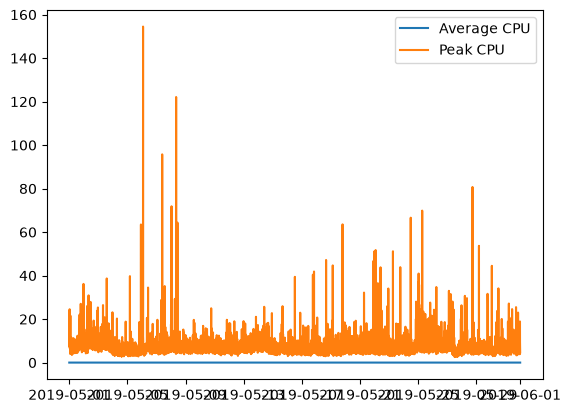

In [42]:
plt.plot(df["datetime"], df["avg_cpu_usage"], label="Average CPU")
plt.plot(df["datetime"], df["peak_cpu_usage"], label="Peak CPU")
plt.legend()
plt.show()

The comparison between average and peak CPU usage shows that average CPU utilization remains relatively stable throughout the month, while peak CPU usage exhibits frequent and sometimes extreme spikes. This indicates that the cluster experiences short periods of concentrated CPU demand that are not visible in the average utilization alone. The presence of these spikes is relevant to predictive autoscaling because relying only on average CPU may delay scaling decisions during sudden high-load events. Therefore, peak CPU behavior and recent CPU changes should be considered alongside average and total CPU usage when designing the forecasting and scaling model.

In [43]:
df["memory_gap"] = (
    df["avg_assigned_memory"]
    - df["avg_memory_usage"]
)

In [44]:
df["memory_gap"].describe()

count    8929.000000
mean        0.004744
std         0.000520
min         0.003563
25%         0.004388
50%         0.004656
75%         0.005074
max         0.007813
Name: memory_gap, dtype: float64

In [45]:
df["total_cpu_usage"].autocorr(lag=1)

np.float64(0.9422564411915846)

In [46]:
for lag in [1, 2, 3, 6, 12, 24, 288]:
    print(lag, df["total_cpu_usage"].autocorr(lag=lag))

1 0.9422564411915846
2 0.887069414363464
3 0.846449240902062
6 0.7648752301321837
12 0.6702939863164482
24 0.5268605904467507
288 0.5456414871879901


In [48]:
df["target_cpu_15min"] = df["total_cpu_usage"].shift(-3)

In [49]:
q90 = df["total_cpu_usage"].quantile(0.90)
q95 = df["total_cpu_usage"].quantile(0.95)
q99 = df["total_cpu_usage"].quantile(0.99)

print("90th percentile:", q90)
print("95th percentile:", q95)
print("99th percentile:", q99)

90th percentile: 4314.1982492
95th percentile: 4410.255824
99th percentile: 4594.1087323599995
